In [1]:
import matplotlib.pyplot as plt
import os.path as op
import xarray as xr
from glob import glob

In [16]:
site = 'Degero'

# 'MYD11A1.061'    # 'MOD13A2.061'       # 'MCD43A3.061'       # 'MCD15A3H.061'     # 'MYD11A1.061'      # 'MCD15A3H.061'
# 'LST_Night_1km'  # '1_km_16_days_EVI'  # 'Albedo_WSA_Band2'  # 'Fpar_500m'        # 'LST_Night_1km'    # 'Lai_500m'
# 0.5              # 0.5                 # 0.5                 # 1.5                # 0.5                # 1.5
# 0.02             # 0.0001              # 0.001               #  0.01              # 0.02               # 0.1

product = 'MYD11A1.061'
variable = 'LST_Night_1km'
smoothing_factor = 0.5
scaling_factor =  0.02

site_path = f'/wp_data/sites/{site}/MODIS'

# Open the files as xarrays
qa_fname = op.join(site_path, 'analytics_QA_settings', f'_{variable}_qa_analytics_mask.tif')
qa_fname = glob(qa_fname)[0]
qa = xr.open_dataset(qa_fname)

lai_fname = op.join(site_path, product, 'h??v??', variable, 'interpolated', f'{product}._{variable}.linear.smoothn.{smoothing_factor}.tif')
# Check if the file exists
lai_fname = glob(lai_fname)[0]
lai = xr.open_dataset(lai_fname)

lai_stddev_weighted_fname = op.join(site_path, product, 'h??v??', variable, 'interpolated', f"{product}._{variable}.linear.smoothn.{smoothing_factor}_qa_weighted_std_dev.tif")
lai_stddev_weighted_fname = glob(lai_stddev_weighted_fname)[0]

lai_stddev_weighted = xr.open_dataset(lai_stddev_weighted_fname)

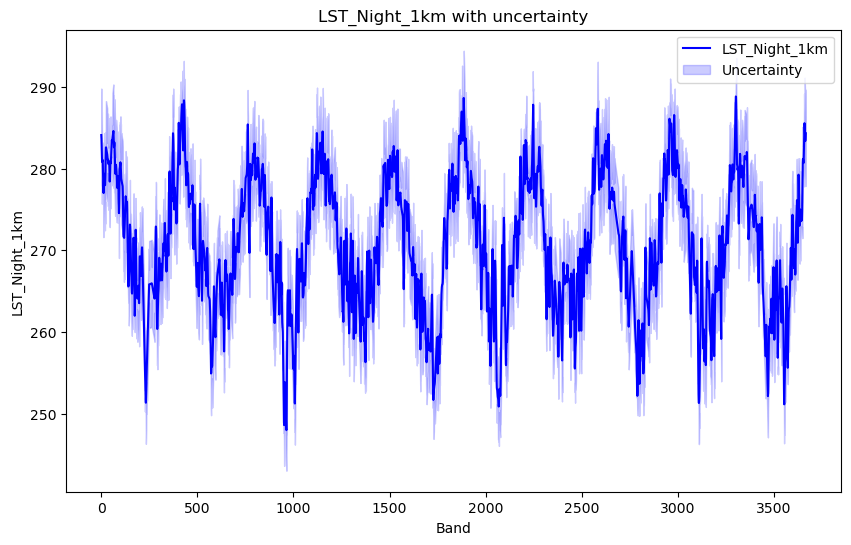

In [17]:
row, col = 12, 12

start_ = 0
end_ = -1

series_qa = qa['band_data'][start_:end_, row, col]
series_lai = lai['band_data'][start_:end_, row, col]
series_lai_stddev_weighted = lai_stddev_weighted['band_data'][start_:end_, row, col]

mean_lai = series_lai * scaling_factor
std_dev_weighted = series_lai_stddev_weighted

plt.figure(figsize=(10, 6))
plt.plot(mean_lai.band, mean_lai, label=variable, color='blue')
plt.fill_between(
    mean_lai.band,
    mean_lai - std_dev_weighted,
    mean_lai + std_dev_weighted,
    color='blue',
    alpha=0.2,
    label='Uncertainty'
)
plt.xlabel('Band')
plt.ylabel(variable)
plt.title(f'{variable} with uncertainty')
plt.legend()
plt.show()
